# Ejercicio 1 – Predicción del rendimiento académico de estudiantes

## Descripción del problema:

El dataset contiene información de estudiantes, donde cada fila representa
un estudiante con variables demográficas, académicas y sociales
(edad, género, apoyo familiar, tiempo de estudio, etc.), junto con su
rendimiento medido por una nota final.

Nuestro objetivo es construir un modelo que clasifique el rendimiento
en tres categorías: "bajo", "medio" y "alto". Esta clasificación puede
apoyar la identificación temprana de estudiantes en riesgo y orientar
acciones de acompañamiento académico.

In [2]:
# Librerías necesarias
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [3]:
PROJECT_ROOT = Path.cwd().parent
file_path = PROJECT_ROOT /"data"/"ejercicio01_student-grades.csv"
df = pd.read_csv(file_path)

In [4]:
df.shape

(395, 33)

El dataset contiene 396 registros y 33 variables lo que proporciona una muestra suficiente para explorar patrones generales de rendimiento estudiantil sin dejar de ser manejable en un
entorno de análisis exploratorio.

In [5]:
df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## Diccionario de variables

| Variable             | Tipo                           | Descripción                                               | Valores posibles / rango                                         |
| -------------------- | ------------------------------ | --------------------------------------------------------- | ---------------------------------------------------------------- |
| school               | Categórica                     | Colegio del estudiante                                    | GP = Gabriel Pereira; MS = Mousinho da Silveira            |
| sex                  | Categórica                     | Sexo del estudiante                                       | F = mujer; M = hombre                                      |
| age                  | Numérica                       | Edad del estudiante                                       | 15 a 22 años aprox.                                        |
| address              | Categórica                     | Tipo de lugar de residencia                               | U = urbano; R = rural                                            |
| famsize              | Categórica                     | Tamaño de la familia                                      | LE3 = ≤ 3; GT3 = > 3 miembros                              |
| Pstatus              | Categórica                     | Estado de convivencia de los padres                       | T = juntos; A = separados                                  |
| Medu                 | Numérica                       | Nivel educativo de la madre                               | 0 = ninguno; 1 = primaria; 2 = 5º–9º; 3 = secundaria; 4 = superior  |
| Fedu                 | Numérica                       | Nivel educativo del padre                                 | Igual codificación que Medu                                |
| Mjob                 | Categórica                     | Ocupación de la madre                                     | teacher, health, services, at_home, other                  |
| Fjob                 | Categórica                     | Ocupación del padre                                       | teacher, health, services, at_home, other                  |
| reason               | Categórica                     | Razón para escoger este colegio                           | home, reputation, course, other                            |
| guardian\| Categórica | Tutor principal del estudiante | mother, father, other                               |                                                                  |
| traveltime           | Numérica                       | Tiempo de desplazamiento casa–colegio                     | 1 = <15 min; 2 = 15–30 min; 3 = 30–60 min; 4 = >1 h        |
| studytime            | Numérica                       | Tiempo de estudio semanal                                 | 1 = <2 h; 2 = 2–5 h; 3 = 5–10 h; 4 = >10 h                 |
| failures             | Numérica                       | Número de asignaturas reprobadas previamente              | n si 1 ≤ n < 3; 4 = 3 o más                                |
| schoolsup            | Categórica                     | Apoyo educativo adicional de la escuela                   | yes / no                                                   |
| famsup               | Categórica                     | Apoyo educativo de la familia                             | yes / no                                                   |
| paid                 | Categórica                     | Clases extra de pago en la materia                        | yes / no                                                   |
| activities           | Categórica                     | Participa en actividades extraescolares                   | yes / no                                                   |
| nursery              | Categórica                     | Asistió a educación preescolar                            | yes / no                                                   |
| higher               | Categórica                     | Desea cursar educación superior                           | yes / no                                                   |
| internet             | Categórica                     | Acceso a internet en casa                                 | yes / no                                                   |
| romantic             | Categórica                     | Tiene relación romántica                                  | yes / no                                                   |
| famrel               | Numérica                       | Calidad de la relación familiar                           | 1 = muy mala, …, 5 = excelente                             |
| freetime             | Numérica                       | Tiempo libre después de clase                             | 1 = muy bajo, …, 5 = muy alto                              |
| goout                | Numérica                       | Frecuencia de salir con amigos                            | 1 = muy bajo, …, 5 = muy alto                              |
| Dalc                 | Numérica                       | Consumo de alcohol entre semana                           | 1 = muy bajo, …, 5 = muy alto                              |
| Walc                 | Numérica                       | Consumo de alcohol en fin de semana                       | 1 = muy bajo, …, 5 = muy alto                              |
| health               | Numérica                       | Estado de salud actual                                    | 1 = muy malo, …, 5 = muy bueno                             |
| absences             | Numérica                       | Número de ausencias a clase                               | 0 a 93                                                     |
| G1                   | Numérica                       | Nota del primer periodo (0–20)                            | 0–20                                                             |
| G2                   | Numérica                       | Nota del segundo periodo (0–20)                           | 0–20 +1                                                          |
| G3                   | Numérica                       | Nota final del curso (0–20), target base para rendimiento | 0–20; muy correlacionada con G1 y G2           |

In [6]:
# Información de tipos y nulos
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

A partir del resumen de `df.info()` se identifican las columnas numéricas y las columnas
categóricas.
El conteo de valores faltantes muestra que:
- Algunas variables no presentan valores nulos.
- Otras variables tienen un número reducido de valores faltantes (por ejemplo, información socioeconómica o de apoyo), que se tratarán posteriormente mediante técnicas de imputación.
Este análisis inicial permite planear el preprocesamiento adecuado y evitar perder registros completos por filas incompletas.

In [7]:
# Estadísticas descriptivas
df.describe(include='all')

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395,395,395.000000,395,395,395,395.000000,395.000000,395,395,...,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
unique,2,2,NaN,2,2,2,NaN,NaN,5,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,GP,F,NaN,U,GT3,T,NaN,NaN,other,other,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,349,208,NaN,307,281,354,NaN,NaN,141,217,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,16.696203,NaN,NaN,NaN,2.749367,2.521519,NaN,NaN,...,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,NaN,NaN,1.276043,NaN,NaN,NaN,1.094735,1.088201,NaN,NaN,...,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,NaN,NaN,15.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,NaN,NaN,16.000000,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN,...,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,NaN,NaN,17.000000,NaN,NaN,NaN,3.000000,2.000000,NaN,NaN,...,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,NaN,NaN,18.000000,NaN,NaN,NaN,4.000000,3.000000,NaN,NaN,...,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000


Se calcularon estadísticas descriptivas básicas (media, desviación estándar, mínimo, máximo y cuartiles) para las variables numéricas, así como frecuencias para las variables categóricas.
A partir de estos estadísticos se observa:
- El rango de edades y la concentración de estudiantes en ciertos tramos.
- El comportamiento de variables como tiempo de estudio u horas de clase.
- La distribución de categorías en variables cualitativas relevantes
  (género, tipo de establecimiento, etc.).

Estos resúmenes permiten detectar valores atípicos evidentes y entender la escala y variabilidad de cada característica antes de aplicar modelos de Machine Learning.

In [8]:
# Conteo de nulos
df.isna().sum().sort_values(ascending=False)

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Podemos evidenciar que no existen nulos en este dataset

In [9]:
# Verificamos la variable de rendimiento (nota final)
df['G3'].describe()

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

Esta variable será la base para construir la variable objetivo de clasificación en tres categorías de rendimiento ("bajo", "medio", "alto")

## Definimos los rangos para clasificar el rendimiento

In [10]:
def convertir_rendimiento(g3):
    if g3 <= 9:
        return 'bajo'
    elif g3 <= 14:
        return 'medio'
    else:
        return 'alto'

df['rendimiento'] = df['G3'].apply(convertir_rendimiento)

df['rendimiento'].value_counts(normalize=True)

rendimiento
medio    0.486076
bajo     0.329114
alto     0.184810
Name: proportion, dtype: float64

# Distribuciones
## - Distribución de la nota final (G3)

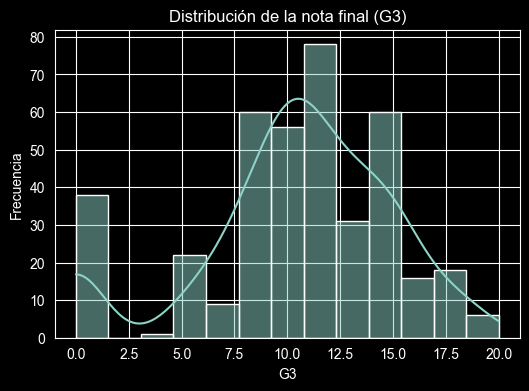

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(df['G3'], kde=True)
plt.title('Distribución de la nota final (G3)')
plt.xlabel('G3')
plt.ylabel('Frecuencia')
plt.show()

## - Distribución de la variable objetivo (rendimiento)

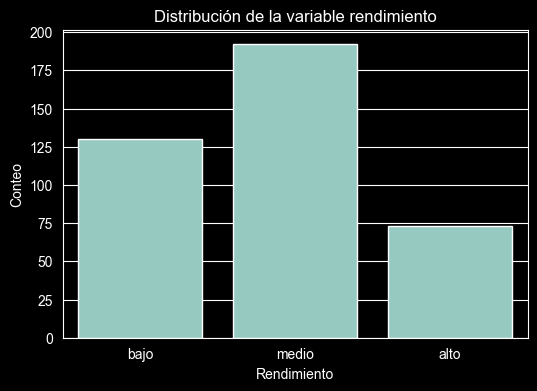

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='rendimiento', data=df,
              order=['bajo','medio','alto'])
plt.title('Distribución de la variable rendimiento')
plt.xlabel('Rendimiento')
plt.ylabel('Conteo')
plt.show()


Podemos ver que la mayoría de estudiantes se concentra en la categoría “medio”, mientras que las clases “bajo” y “alto” cuentan con menos observaciones. Esto indica cierto desbalance en la variable objetivo, que se tendrá en cuenta al interpretar las métricas de los modelos

## - Distribución de edades por nivel de rendimiento

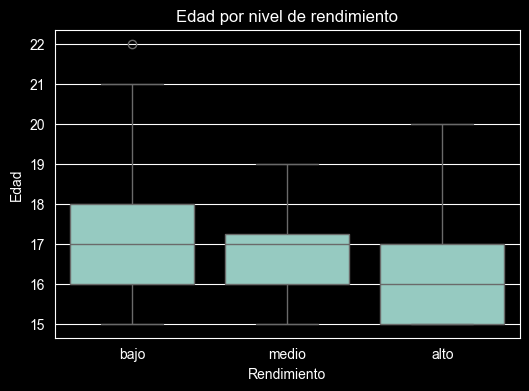

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(x='rendimiento', y='age', data=df,
            order=['bajo','medio','alto'])
plt.title('Edad por nivel de rendimiento')
plt.xlabel('Rendimiento')
plt.ylabel('Edad')
plt.show()

Podemos observar que los estudiantes con peor rendimiento suelen ser los estudiantes con edades entre 16 y 18 años

## - Ausencias por rendimiento

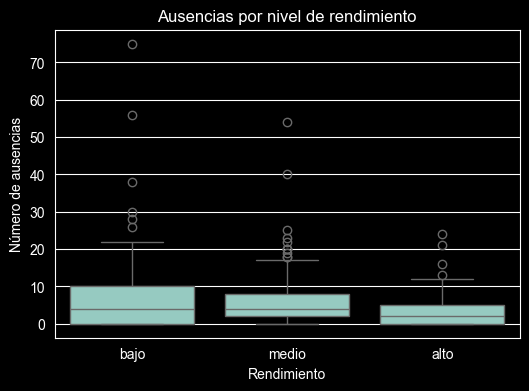

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x='rendimiento', y='absences', data=df,
            order=['bajo','medio','alto'])
plt.title('Ausencias por nivel de rendimiento')
plt.xlabel('Rendimiento')
plt.ylabel('Número de ausencias')
plt.show()

El diagrama de caja de `absences` por categoría de `rendimiento` muestra que los estudiantes con rendimiento "bajo" tienden a presentar un número de ausencias mayor y más disperso que quienes se ubican en "medio" o
"alto". Esto respalda la idea de que la inasistencia frecuente puede estar asociada con un peor desempeño académico.

# Análisis de subgrupos
## - Rendimiento por sexo

rendimiento  alto  bajo  medio
sex                           
F              32    75    101
M              41    55     91


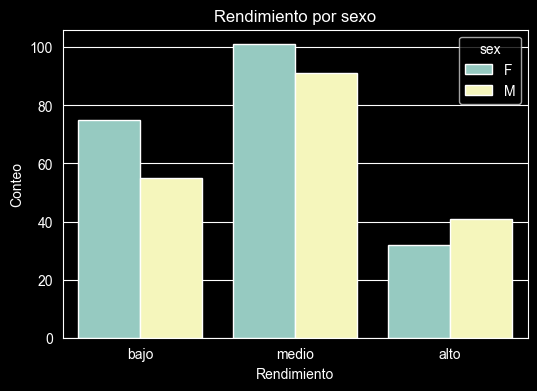

In [15]:
# Conteo absoluto
ct_sex = pd.crosstab(df['sex'], df['rendimiento'])
print(ct_sex)

# Proporción por sexo
ct_sex_prop = pd.crosstab(df['sex'], df['rendimiento'], normalize='index')
ct_sex_prop

plt.figure(figsize=(6,4))
sns.countplot(x='rendimiento', hue='sex', data=df,
              order=['bajo','medio','alto'])
plt.title('Rendimiento por sexo')
plt.xlabel('Rendimiento')
plt.ylabel('Conteo')
plt.show()

rendimiento  alto  bajo  medio
famsup                        
no             31    45     77
yes            42    85    115


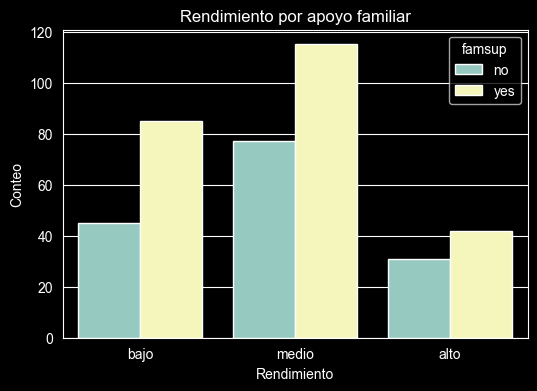

In [16]:
# Conteo absoluto
ct_famsup = pd.crosstab(df['famsup'], df['rendimiento'])
print(ct_famsup)
# Proporción por apoyo familiar
ct_famsup_prop = pd.crosstab(df['famsup'], df['rendimiento'], normalize='index')

plt.figure(figsize=(6,4))
sns.countplot(x='rendimiento', hue='famsup', data=df,
              order=['bajo','medio','alto'])
plt.title('Rendimiento por apoyo familiar')
plt.xlabel('Rendimiento')
plt.ylabel('Conteo')
plt.show()

Al segmentar el rendimiento según la variable `famsup` (apoyo educativo de la familia) se observa que los estudiantes que cuentan con apoyo tienden a presentar una mayor proporción de casos en las categorías
"medio" y "alto", mientras que entre quienes no tienen apoyo la proporción de "bajo" es ligeramente mayor.

## - Rendimiento por estado de convivencia de los padres

rendimiento  alto  bajo  medio
Pstatus                       
A               9    11     21
T              64   119    171


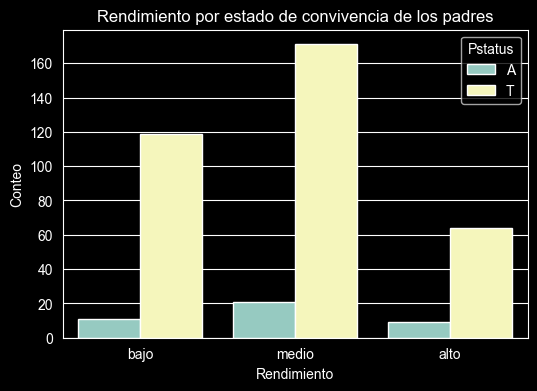

In [17]:
# Conteo absoluto
ct_pstatus = pd.crosstab(df['Pstatus'], df['rendimiento'])
print(ct_pstatus)
# Proporción por estado de convivencia de los padres
ct_pstatus = pd.crosstab(df['Pstatus'], df['rendimiento'], normalize='index')

plt.figure(figsize=(6,4))
sns.countplot(x='rendimiento', hue='Pstatus', data=df,
              order=['bajo','medio','alto'])
plt.title('Rendimiento por estado de convivencia de los padres')
plt.xlabel('Rendimiento')
plt.ylabel('Conteo')
plt.show()

Podemos observar que entre los estudiantes con padres juntos (`Pstatus = T`) la proporción
  de casos en "alto" y "medio" rendimiento es ligeramente mayor. Este patrón sugiere que el estado
de convivencia de los padres podría estar relacionado con el rendimiento académico. Sin embargo, se trata solo de una asociación observacional y no permite concluir causalidad.

# Correlaciones

In [18]:
# Seleccionamos las variables numéricas
numeric_cols = [
    'age', 'Medu', 'Fedu', 'traveltime', 'studytime',
    'failures', 'famrel', 'freetime', 'goout', 'Dalc',
    'Walc', 'health', 'absences', 'G1', 'G2', 'G3'
]

corr = df[numeric_cols].corr()
corr

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
age,1.000000,-0.163658,-0.163438,0.070641,-0.004140,0.243665,0.053940,0.016434,0.126964,0.131125,0.117276,-0.062187,0.175230,-0.064081,-0.143474,-0.161579
Medu,-0.163658,1.000000,0.623455,-0.171639,0.064944,-0.236680,-0.003914,0.030891,0.064094,0.019834,-0.047123,-0.046878,0.100285,0.205341,0.215527,0.217147
Fedu,-0.163438,0.623455,1.000000,-0.158194,-0.009175,-0.250408,-0.001370,-0.012846,0.043105,0.002386,-0.012631,0.014742,0.024473,0.190270,0.164893,0.152457
traveltime,0.070641,-0.171639,-0.158194,1.000000,-0.100909,0.092239,-0.016808,-0.017025,0.028540,0.138325,0.134116,0.007501,-0.012944,-0.093040,-0.153198,-0.117142
studytime,-0.004140,0.064944,-0.009175,-0.100909,1.000000,-0.173563,0.039731,-0.143198,-0.063904,-0.196019,-0.253785,-0.075616,-0.062700,0.160612,0.135880,0.097820
failures,0.243665,-0.236680,-0.250408,0.092239,-0.173563,1.000000,-0.044337,0.091987,0.124561,0.136047,0.141962,0.065827,0.063726,-0.354718,-0.355896,-0.360415
famrel,0.053940,-0.003914,-0.001370,-0.016808,0.039731,-0.044337,1.000000,0.150701,0.064568,-0.077594,-0.113397,0.094056,-0.044354,0.022168,-0.018281,0.051363
freetime,0.016434,0.030891,-0.012846,-0.017025,-0.143198,0.091987,0.150701,1.000000,0.285019,0.209001,0.147822,0.075733,-0.058078,0.012613,-0.013777,0.011307
goout,0.126964,0.064094,0.043105,0.028540,-0.063904,0.124561,0.064568,0.285019,1.000000,0.266994,0.420386,-0.009577,0.044302,-0.149104,-0.162250,-0.132791
Dalc,0.131125,0.019834,0.002386,0.138325,-0.196019,0.136047,-0.077594,0.209001,0.266994,1.000000,0.647544,0.077180,0.111908,-0.094159,-0.064120,-0.054660


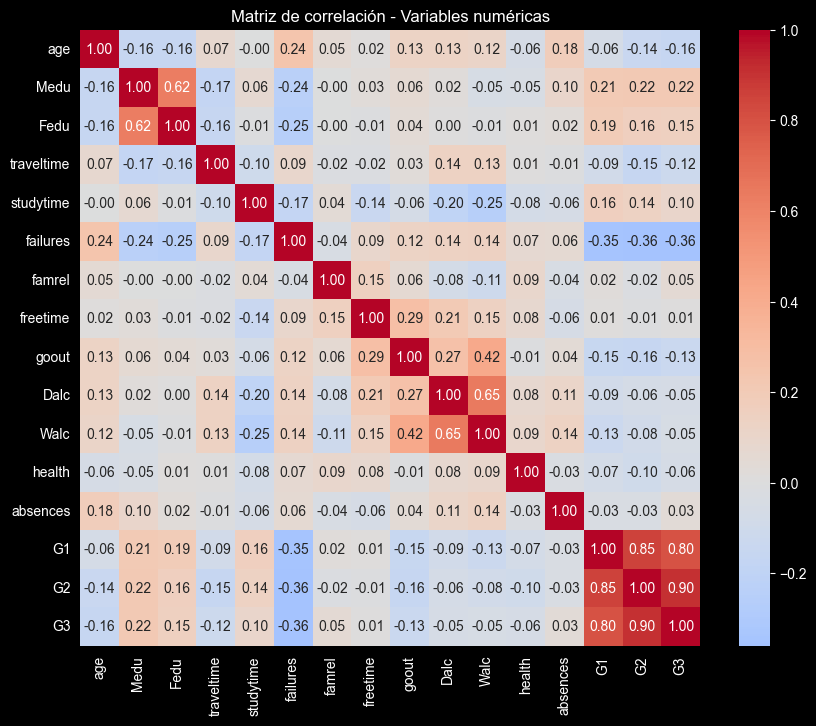

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Matriz de correlación - Variables numéricas')
plt.show()

In [20]:
# Vemos las correlaciones concretas con la nota final (G3)
corr_G3 = corr['G3'].sort_values(ascending=False)
corr_G3

G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64

La matriz de correlación revela que la nota final `G3` presenta una correlación muy alta con las notas de los periodos anteriores `G1` y `G2`, lo cual es esperable porque las tres calificaciones miden el rendimiento
del estudiante a lo largo del mismo curso. Estas relaciones cuantitativas ayudan a identificar qué factores podrían
ser más relevantes para los modelos de clasificación y a interpretar mejor
sus resultados posteriores.

# Preprocesamiento

In [21]:
# Separamos X (features) y y (target)

# y: variable objetivo categórica
y = df['rendimiento']

# X: todas las demás columnas menos G3 y rendimiento
X = df.drop(columns=['rendimiento', 'G3'])

X.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,4,3,4,1,1,3,6,5,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,no,5,3,3,1,1,3,4,5,5
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,no,4,3,2,2,3,3,10,7,8
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,3,2,2,1,1,5,2,15,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,4,3,2,1,2,5,4,6,10


In [22]:
# Definimos las columnas numéricas y categóricas
numeric_features = [
    'age', 'Medu', 'Fedu', 'traveltime', 'studytime',
    'failures', 'famrel', 'freetime', 'goout', 'Dalc',
    'Walc', 'health', 'absences', 'G1', 'G2'
]

categorical_features = [
    'school', 'sex', 'address', 'famsize', 'Pstatus',
    'Mjob', 'Fjob', 'reason', 'guardian',
    'schoolsup', 'famsup', 'paid', 'activities',
    'nursery', 'higher', 'internet', 'romantic'
]

# Imputación, estandarización y codificación

In [23]:
# Pipeline para columnas numéricas: imputar + escalar
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para columnas categóricas: imputar + One-Hot
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# ColumnTransformer que aplica cada pipeline a su grupo de columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

Para preparar los datos antes de entrenar los modelos se separó la matriz de características `X` de la variable objetivo categórica `rendimiento`. Las columnas numéricas (edad, educación de los padres, tiempo de estudio,
ausencias, notas parciales, etc.) se procesan mediante un pipeline que aplica imputación por mediana y estandarización con `StandardScaler`, lo cual es importante para algoritmos sensibles a la escala como
Regresión Logística, KNN y SVM.

# Modelo 1-  Regresión logística

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(316, 32) (79, 32)
rendimiento
medio    0.487342
bajo     0.329114
alto     0.183544
Name: proportion, dtype: float64
rendimiento
medio    0.481013
bajo     0.329114
alto     0.189873
Name: proportion, dtype: float64


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Pipeline completo: preprocesamiento + modelo
logreg_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Entrenamiento
logreg_model.fit(X_train, y_train)

# Predicción
y_pred_logreg = logreg_model.predict(X_test)

# Métricas
acc_logreg = accuracy_score(y_test, y_pred_logreg)
prec_logreg = precision_score(y_test, y_pred_logreg, average='weighted')
rec_logreg = recall_score(y_test, y_pred_logreg, average='weighted')
f1_logreg = f1_score(y_test, y_pred_logreg, average='weighted')

print("Accuracy:", acc_logreg)
print("Precision:", prec_logreg)
print("Recall:", rec_logreg)
print("F1-score:", f1_logreg)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_logreg))

Accuracy: 0.8607594936708861
Precision: 0.862966889069028
Recall: 0.8607594936708861
F1-score: 0.8603149581474533

Classification Report:

              precision    recall  f1-score   support

        alto       0.87      0.87      0.87        15
        bajo       0.83      0.92      0.87        26
       medio       0.89      0.82      0.85        38

    accuracy                           0.86        79
   macro avg       0.86      0.87      0.86        79
weighted avg       0.86      0.86      0.86        79



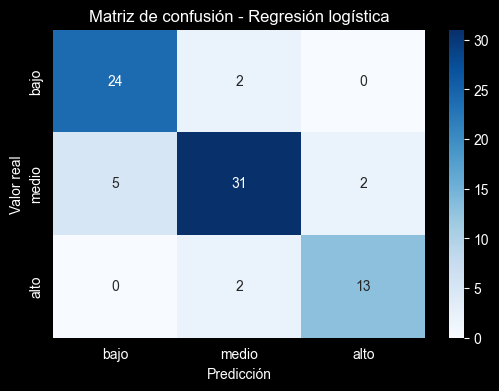

In [27]:
cm_logreg = confusion_matrix(y_test, y_pred_logreg, labels=['bajo','medio','alto'])

plt.figure(figsize=(6,4))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['bajo','medio','alto'],
            yticklabels=['bajo','medio','alto'])
plt.title('Matriz de confusión - Regresión logística')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

# Visualización con PCA

In [28]:
from sklearn.decomposition import PCA

# 1) Ajustar preprocessor solo con datos X (sin el clasificador)
X_preprocessed = preprocessor.fit_transform(X)

# 2) PCA a 2 componentes
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_preprocessed)

# 3) DataFrame para graficar
pca_df = pd.DataFrame(X_pca, columns=['PC1','PC2'])
pca_df['rendimiento'] = y.values

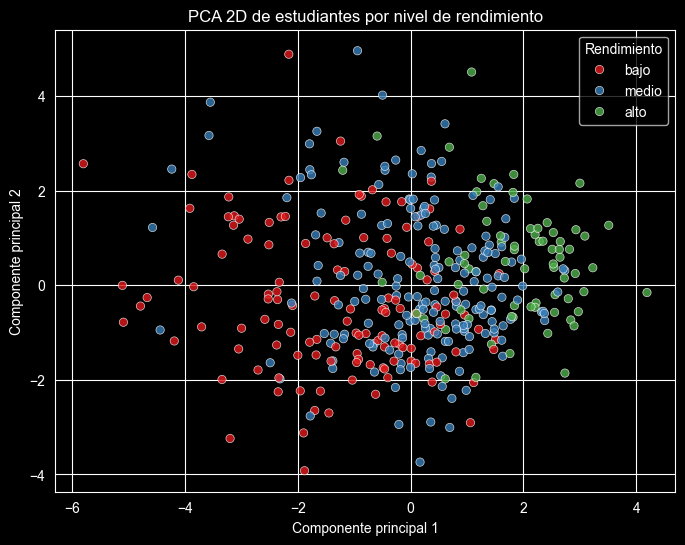

In [29]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='rendimiento',
    hue_order=['bajo','medio','alto'],
    palette='Set1',
    alpha=0.8
)
plt.title('PCA 2D de estudiantes por nivel de rendimiento')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.legend(title='Rendimiento')
plt.show()

En la visualización podemos observar que los estudiantes de las tres categorías de rendimiento ("bajo", "medio" y "alto") ocupan una región común del espacio y presentan solapamiento, aunque se observan zonas donde los casos de rendimiento "alto" tienden a concentrarse hacia valores más altos del primer componente, mientras que varios casos de rendimiento "bajo" se extienden hacia la parte izquierda del plano. Esto indica que los modelos de clasificación disponen de cierta estructura en los datos para diferenciar niveles de rendimiento, pero también que la separación entre clases no es perfecta ni puramente lineal en dos dimensiones, por lo que es esperable que se cometan errores de clasificación.

# Tabla de métricas globales
| Modelo                | Accuracy | Precision | Recall | F1-score |
|-----------------------|----------|-----------|--------|----------|
| Regresión Logística   | 0.86      | 0.86      | 0.86   | 0.86     |
| KNN                   | 0.xx     | 0.xx      | 0.xx   | 0.xx     |
| Random Forest / SVM   | 0.xx     | 0.xx      | 0.xx   | 0.xx     |